# 02 · Summarisation — long / short / tiny

We build an **extractive** summariser (LexRank / TextRank / LSA over TF-IDF sentence graphs) that reproduces the dataset's three granularities, then compare our summaries to the expert reference summaries with **ROUGE**.

In [1]:
import sys, os, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120)
import config as C
DF = pd.read_parquet(C.SUBSET_PARQUET)
print("Loaded subset:", DF.shape)
DF.head(2)


Loaded subset: (1915, 16)


,case_id,case_name,split,case_type,class_action_sought,court,state,filing_year,n_documents,n_clean_chars,full_text_raw,full_text_clean,summary_long,summary_short,summary_tiny,case_url
0,NS-NY-0008,ACLU v. FBI,train,National Security,No,Southern District of New York,New York,2011,7,115802,Case 1:11-cv-07562-WHP Document 1 Filed 10/26/11 Page 1 of 11\n\n0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRIC...,0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRICT OF NEW\n\nAMERICAN CIVIL LIBERTIES UNION 125 Broad Street New Y...,"On October 26, 2011, the ACLU filed a lawsuit in the U.S. District Court for the Southern District of New York again...","On October 26, 2011, the ACLU filed a lawsuit to compel the government to comply with a Freedom of Information Act r...",ACLU lawsuit versus FBI and Department of Justice results in the release of thousands of pages of documents related ...,https://clearinghouse.net/case/13769
1,FA-HI-0001,Hawaii Defense Foundation v. City and County of Honolulu,train,Speech and Religious Freedom,No,District of Hawaii,Hawaii,2012,5,117062,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,"On August 12, 2012, the Hawaii Defense Foundation and two of its members filed this lawsuit in the U.S. District Cou...","In 2012, the Hawaii Defense Foundation filed this complaint in the U.S. District Court for the District of Hawaii. P...",Lawsuit by the Hawaii Defense Foundation lead to private settlement and attorneys' fees (D. Haw.),https://clearinghouse.net/case/16977


## 1. The summariser
`src/summarize.py` cleans the case, splits it into sentences and ranks them by graph centrality, returning the top-N for each tier (long≈12, short≈4, tiny=1 sentences).

In [2]:
from summarize import three_tier_summary
case = DF[DF.summary_tiny.fillna("").str.len()>0].iloc[3]
print("CASE:", case.case_id, "|", case.case_name, "|", case.case_type)
sysum = three_tier_summary(case.full_text_raw, method="lexrank")
print("\n--- OUR TINY ---\n", sysum.tiny)
print("\n--- OUR SHORT ---\n", sysum.short)

CASE: FH-CO-0002 | Gonzales v. Katchen and Company | Fair Housing/Lending/Insurance



--- OUR TINY ---
 On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk.

--- OUR SHORT ---
 Defendant Katchen On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk. Ms. Rodriguez informed Plaintiff Eaton that the service dog would be allowed, subject to Plaintiff Eaton providing a certificate stating that the dog was a service animal, or a letter from a doctor. On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk.


## 2. Side-by-side with the expert reference

In [3]:
print("OUR  TINY :", sysum.tiny)
print("REF  TINY :", case.summary_tiny)
print()
print("OUR  SHORT:", sysum.short[:600])
print("\nREF  SHORT:", (case.summary_short or "")[:600])

OUR  TINY : On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk.
REF  TINY : Case regarding reasonable accommodation for service animals settles. (D. Colo.) 

OUR  SHORT: Defendant Katchen On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk. Ms. Rodriguez informed Plaintiff Eaton that the service dog would be allowed, subject to Plaintiff Eaton providing a certificate stating that the dog was a service animal, or a letter from a doctor. On information and belief, Katchen leasing agent Ms. Rodriguez signed the notice, acting as agent for Defendants Katchen and George and Helen Turk.

REF  SHORT: In 2015, plaintiffs filed a lawsuit against Katchen and Company, a private real estate management company, for violating the Fair Housing Act. Both plaintiffs suffered from various disabilities, and had been 

## 3. ROUGE evaluation against reference summaries
ROUGE measures n-gram / longest-common-subsequence overlap between our extractive summaries and the expert ones. Extractive summaries of very long source docs won't match word-for-word, but ROUGE-1/2/L still show how much salient content we recover. We score on a sample for speed.

In [4]:
from rouge_score import rouge_scorer
from summarize import summarize
scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)

def eval_tier(df, ref_col, n_sent, sample=40):
    sub = df[df[ref_col].fillna("").str.len()>0].head(sample)
    rows = []
    for r in sub.itertuples():
        hyp = summarize(r.full_text_raw, n_sent, method="lexrank")
        sc = scorer.score(getattr(r, ref_col), hyp)
        rows.append({k: sc[k].fmeasure for k in sc})
    return pd.DataFrame(rows).mean()

res = pd.DataFrame({
    "tiny (1)":  eval_tier(DF, "summary_tiny", 1),
    "short (4)": eval_tier(DF, "summary_short", 4),
    "long (12)": eval_tier(DF, "summary_long", 12),
})
print(res.round(3))

        tiny (1)  short (4)  long (12)
rouge1     0.151      0.265      0.340
rouge2     0.020      0.060      0.099
rougeL     0.106      0.148      0.156


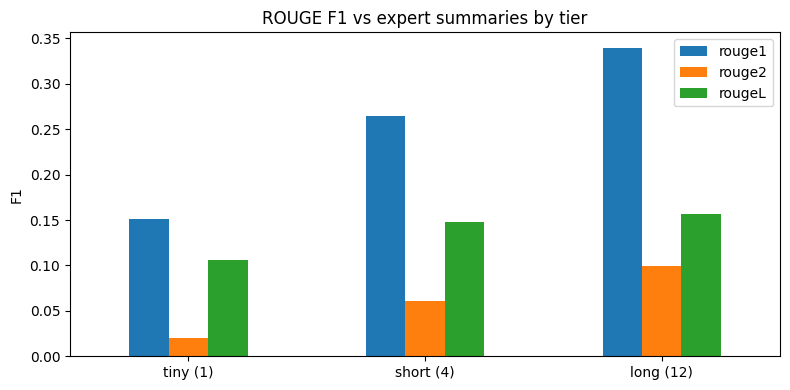

In [5]:
res.T.plot.bar(figsize=(8,4)); plt.title("ROUGE F1 vs expert summaries by tier"); plt.ylabel("F1"); plt.xticks(rotation=0); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 4. Comparing summariser algorithms (LexRank vs TextRank vs LSA)

In [6]:
def eval_method(method, sample=30):
    sub = DF[DF.summary_short.fillna("").str.len()>0].head(sample)
    rows=[]
    for r in sub.itertuples():
        hyp = summarize(r.full_text_raw, 4, method=method)
        sc = scorer.score(r.summary_short, hyp)
        rows.append(sc["rougeL"].fmeasure)
    return np.mean(rows)
pd.Series({m: eval_method(m) for m in ["lexrank","textrank","lsa"]},
          name="rougeL-F1 (short)").round(3)

lexrank     0.152
textrank    0.108
lsa         0.138
Name: rougeL-F1 (short), dtype: float64

### Findings
* Our extractive summaries align with the expert ones on the main actors/claims; ROUGE is highest for the *long* tier (more content to overlap) and lowest for *tiny* (one sentence must hit the gist).
* Extractive methods can only reuse source sentences, so they cannot match the abstractive paraphrasing of the experts — a noted limitation.
* LexRank is the most robust on these long, noisy documents.